In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob

In [3]:
import dask

In [4]:
# set up constants
_SITE = "RGL"
_DATE = "202002"
_HEIGHT = "90magl"

## lat/lon zoomed in around RGL
slice_uk = {"lat": slice(40, 60), "lon": slice(-20, 10)}

In [5]:
from plotting_tools import load_fp, load_flux, load_obs

In [6]:
fps = load_fp(_SITE, _DATE, _HEIGHT)
obs = load_obs(_SITE, _DATE, _HEIGHT)
hourly_means = load_obs(_SITE, _DATE, _HEIGHT, mode="hourly")
fps.load()
obs.load()
hourly_means.load()

release_coords = {"lat":fps.isel(time=0).release_lat.values, "lon":fps.isel(time=0).release_lon.values}

In [7]:
time="2020-02-14T12:00:00"
time_idx = 100

In [8]:
## this controls wether the graphs are static or interactive!
%matplotlib widget

In [9]:
from plotting_tools import plot_footprint, plot_timeseries, make_figure


In [10]:
time_idx= 100

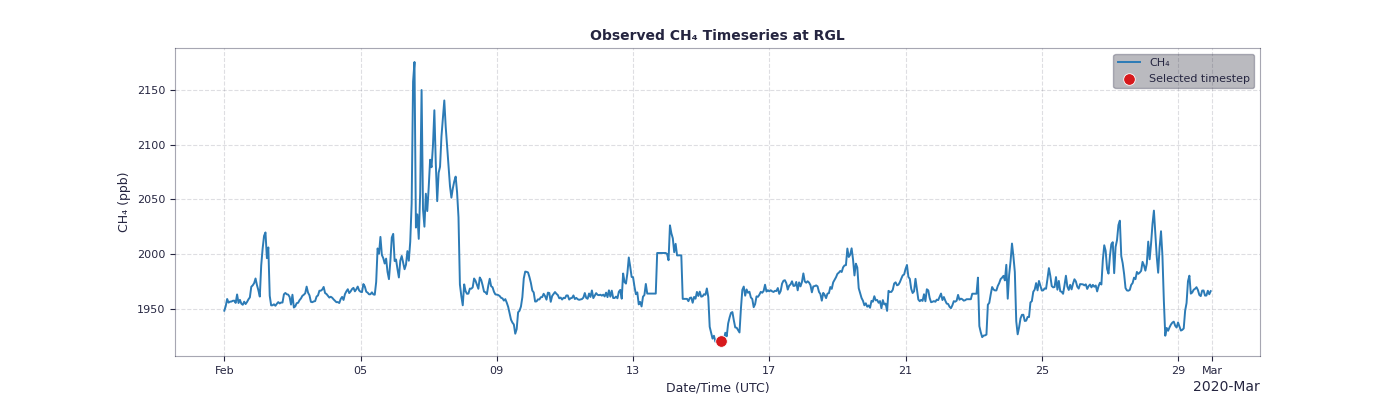

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_timeseries(ax, hourly_means, time_idx="2020-02-15T14:00:00", site=_SITE) # , subset= ("2020-02-10", "2020-02-28")
#obs.ch4.plot(ax=ax, color="green", label="Observations", zorder=3)

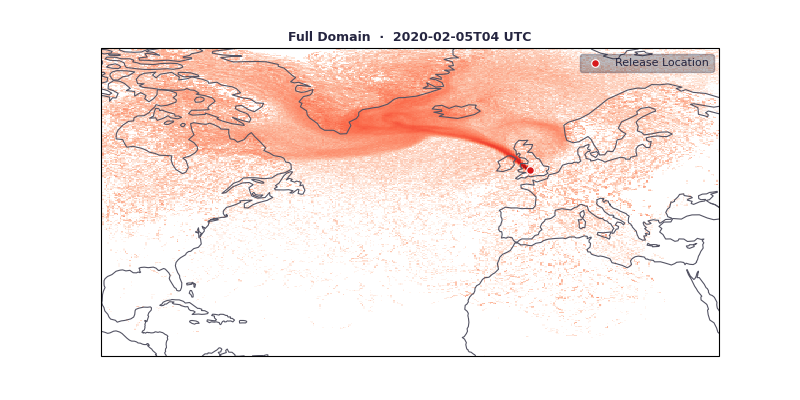

In [12]:
fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": ccrs.PlateCarree()})
plot_footprint(ax, fps, hourly_means, time_idx, release_coords=release_coords, cmap="Reds")#, slice_dict=slice_uk)

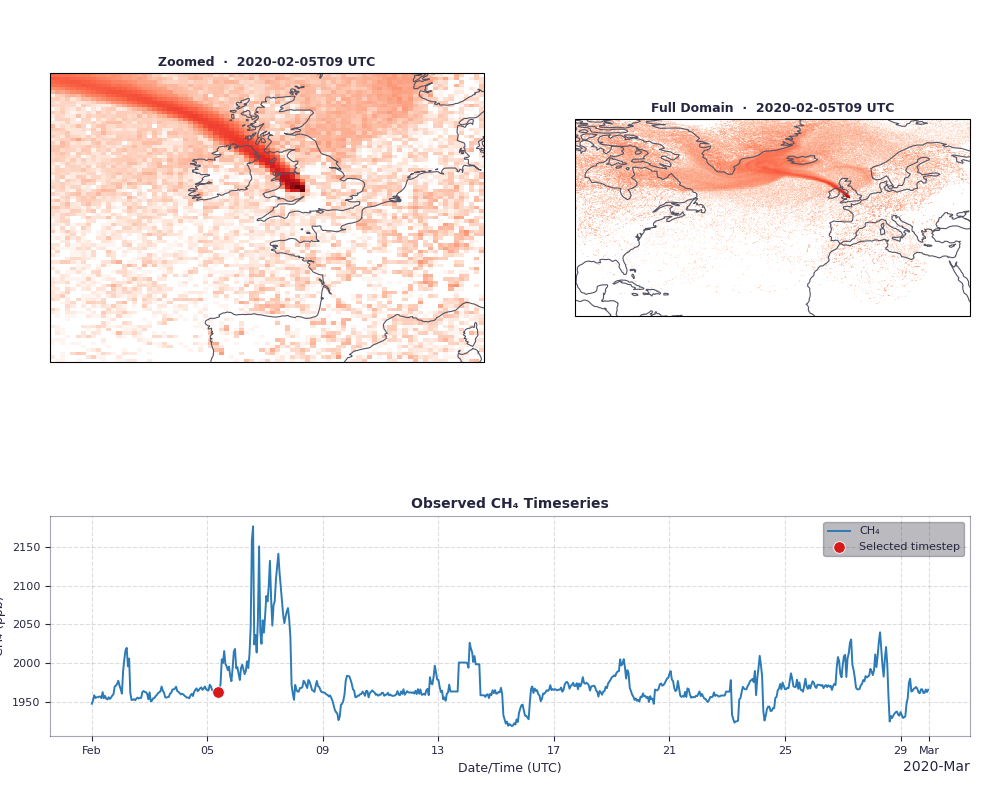

In [13]:
## MAKE STATIC FIGURE for a particular datapoint
fig, _ = make_figure(fps, hourly_means, slice_uk, time_idx=105, interactive=False)

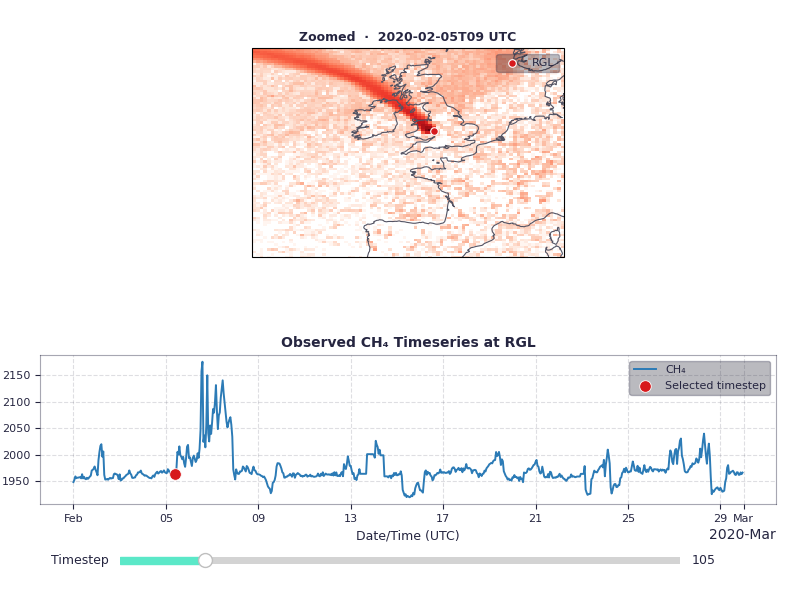

In [16]:
# MAKE INTERACTIVE FIGURE with slider
fig, slider = make_figure(
    fps, hourly_means, slice_uk,
    time_idx=105, interactive=True, figsize=(8,6), release_coords=release_coords, site=_SITE
)

In [17]:
flux = load_flux("EUROPE", "2021")

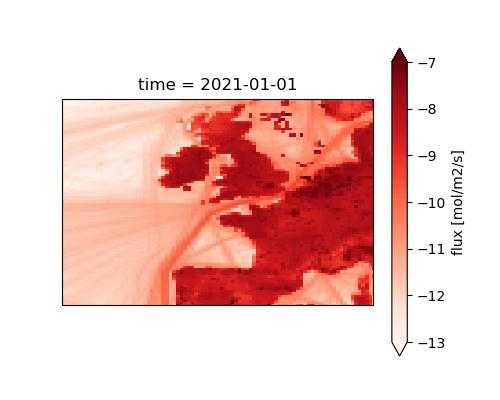

In [23]:
fig, ax = plt.subplots(figsize=(5,4), subplot_kw={"projection": ccrs.PlateCarree()})
np.log10(flux.flux.squeeze()).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="Reds", extend="both", vmin=-13, vmax=-7
    )
ax.set_extent(
    [slice_uk["lon"].start, slice_uk["lon"].stop, slice_uk["lat"].start, slice_uk["lat"].stop],
    crs=ccrs.PlateCarree(),
)
#ax.coastlines()